## Implémentation du solveur de Helmholtz 2D en configuration bipériodique, avec CLs de Dirichlet. Ici, pour éviter d'avoir à inverser $Nx$ fois un système linéaire, nous préfactorisons d'abord la matrice $F$ (décomposition LU)

In [21]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [22]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr

import matplotlib.colors as colors

#module "maison"
import Chebyshev

In [23]:
Chebyshev.Cheb_mat(8).shape

(8, 8)

On résout 
$$
\left(\partial_y^2+\partial_x^2-\alpha^2\right)\psi(x, y) = RHS(x, y)
$$
sur $x, y \in [-1, 1]$, avec $\psi(x, y=\pm 1) = \pm \cosh(l)\cos(kx)$. La solution est $\psi(x, y) = \cos(kx)\cosh(ly)$ pour $\alpha^2 = k^2-l^2$ et $RHS = \left(l^2 -k^2 - \alpha^2\right)\cos{kx}\cosh{ly}$
Ici, $\alpha^2 = 3$, $k=2$, $l=1$, ce qui donne $RHS = -6\cos{kx}\cosh{ly}$


Au début, on prends $\psi(x, y) = \cosh(y)$, $\psi(x, \pm 1) = \pm \cosh(1)$, $\alpha = 2$, $RHS(x, y) = -\cosh(y)$

In [120]:
def Solve_Helmholtz(Nx,
                    Ny,
                    alpha2 = 0.0,
                    rhs=0.0,
                    CL_y_inf = 0.0,
                    CL_y_sup = 0.0,
                    interval_x = (0.0, 2.0*np.pi),
                    interval_y = (-1.0, 1.0) ): 
    #génération de la grille
    x = np.linspace(interval_x[0], interval_x[1], Nx, endpoint = False)
    y = Chebyshev.collocation_points(Ny, a = interval_y[0], b = interval_y[1])

    kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (interval_x[-1] - interval_x[0])/Nx)
    
    if np.isscalar(rhs) : 
        #print(f"RHS scalar")
        RHS = rhs *np.ones((Nx, Ny))
    elif isinstance(rhs, np.ndarray) and (rhs.shape[0] == Nx or rhs.shape[1] == Ny) : 
        RHS = rhs.copy()
    else:
        raise ValueError(f"rhs must be of size Nx x Ny (rhs.shape = {rhs.shape})")
    
    psi_num = np.zeros((Nx, Ny))
    psi_num_hat = np.zeros((Nx, Ny), dtype = 'complex')
    rhs_hat = scipy.fft.fft(RHS, axis = 0)
    
    
    D = Chebyshev.Cheb_mat(Ny, a = interval_y[0], b = interval_y[1])
    D2 = D@D
    
    if np.isscalar(CL_y_inf) : 
        BC_y_inf = np.ones(Nx) * CL_y_inf
        #print("CL_inf scalar")
    elif ( isinstance(CL_y_inf, np.ndarray) == True ) and ( CL_y_inf.shape[0] == Nx and len(CL_y_inf.shape) == 1 ): 
        #print("CL_inf array")
        BC_y_inf = CL_y_inf.copy()
    else : 
        raise ValueError(f"CL_y_inf must be scalar or 1D array of size Nx (CL_y_inf = {CL_y_inf}")

    if np.isscalar(CL_y_sup) : 
        #print("CL_sup_scalar")
        BC_y_sup = np.ones(Nx) * CL_y_sup
    elif ( isinstance(CL_y_sup, np.ndarray) == True ) and ( CL_y_sup.shape[0] == Nx and len(CL_y_sup.shape) == 1 ): 
        #print("CL_sup array")
        BC_y_sup = CL_y_sup.copy()
    else : 
        raise ValueError(f"CL_y_sup must be scalar or 1D array of size Nx (CL_y_sup = {CL_y_sup}")

    BC_y_inf_hat = scipy.fft.fft(BC_y_inf)
    BC_y_sup_hat = scipy.fft.fft(BC_y_sup)
    #pré-construction et factorisation des matrices
    liste_piv = [0 for i in range(0, Nx)]
    liste_F_fac = [0 for i in range(0, Nx)]
    #"""
    alpha_Id = alpha2*np.eye(Ny)
    print("Préfactorisation")
    t0 = time.time()
    for i in range(0, Nx):
        F_i = np.zeros((Ny, Ny))
        np.fill_diagonal(F_i,  -(alpha2+kx[i]**2))
        F_i[1:-1, :] += D2[1:-1,:]
        F_i[0, 0]=1.0
        F_i[-1, -1] = 1.0
        lu_i, piv_i = scipy.linalg.lu_factor(F_i)
        liste_piv[i] = piv_i
        liste_F_fac[i] = lu_i
    print(f"Fait en {time.time() -t0:.3f} sec")
    #Résolution sur les bords extérieurs
    print(f"Résolution sur tout le domaine")
    t1 = time.time()
    for i in range(0, Nx):
        rhs_hat_i = rhs_hat[i, :].copy()

        BC_hat_inf_i = BC_y_inf_hat[i].copy()
        BC_hat_sup_i = BC_y_sup_hat[i].copy()

        rhs_hat_i[0] = BC_hat_sup_i
        rhs_hat_i[-1] = BC_hat_inf_i

        psi_num_hat[i, :] = scipy.linalg.lu_solve((liste_F_fac[i], liste_piv[i]), rhs_hat_i)
    #"""
    """
    alpha_Id = alpha2*np.eye(Ny-2)
    print("Préfactorisation")
    t0 = time.time()
    for i in range(0, Nx):
        F_i = np.zeros((Ny-2, Ny-2))
        np.fill_diagonal(F_i,  -(alpha2+kx[i]**2))
        F_i += D2[1:-1,1:-1].copy()
        if i==1:
            print(F_i)
        lu_i, piv_i = scipy.linalg.lu_factor(F_i)
        liste_piv[i] = piv_i
        liste_F_fac[i] = lu_i
    print(f"Fait en {time.time() -t0:.3f} sec")
    #Résolution sur les bords intérieurs
    print(f"Résolution sur les bords intérieurs")
    t1 = time.time()
    for i in range(0, Nx):
        rhs_hat_i = rhs_hat[i, 1:-1].copy()
        coeff_BC_sup = D2[1:-1, 0].copy()
        #coeff_BC_sup[0] -= (alpha2+kx[i]**2)

        coeff_BC_inf = D2[1:-1, -1].copy()
        
        rhs_hat_BC = rhs_hat_i - coeff_BC_sup*BC_y_sup_hat[i] - coeff_BC_inf*BC_y_inf_hat[i]
        psi_num_hat[i, 1:-1] = scipy.linalg.lu_solve((liste_F_fac[i], liste_piv[i]), rhs_hat_BC)
        psi_num_hat[i, 0] = BC_y_sup_hat[i]
        psi_num_hat[i, -1] = BC_y_sup_hat[i]
    """
    print(f"Fait en {time.time() -t1:.3f} secondes")
    psi_num = scipy.fft.ifft(psi_num_hat, axis = 0).real
    
    return psi_num
    

Nx = 128
Ny = 128
X.shape (128, 128)
Y.shape (128, 128)
alpha^2 2.0
Préfactorisation
Fait en 0.037 sec
Résolution sur tout le domaine
Fait en 0.012 secondes
err [[4.72599737e-12 4.72555328e-12 4.71933603e-12 ... 2.22044605e-16
  2.22044605e-16 0.00000000e+00]
 [4.72599737e-12 4.72555328e-12 4.71933603e-12 ... 2.22044605e-16
  2.22044605e-16 0.00000000e+00]
 [4.72599737e-12 4.72555328e-12 4.71933603e-12 ... 2.22044605e-16
  2.22044605e-16 0.00000000e+00]
 ...
 [4.72599737e-12 4.72555328e-12 4.71933603e-12 ... 2.22044605e-16
  2.22044605e-16 0.00000000e+00]
 [4.72599737e-12 4.72555328e-12 4.71933603e-12 ... 2.22044605e-16
  2.22044605e-16 0.00000000e+00]
 [4.72599737e-12 4.72555328e-12 4.71933603e-12 ... 2.22044605e-16
  2.22044605e-16 0.00000000e+00]], min = 0.0, max = 4.725997371224366e-12, mediane = 1.0308420783644578e-12


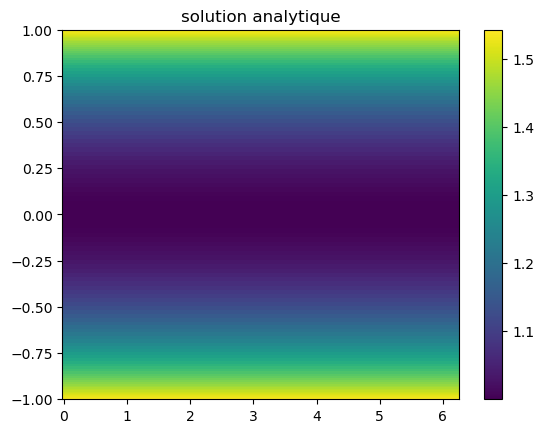

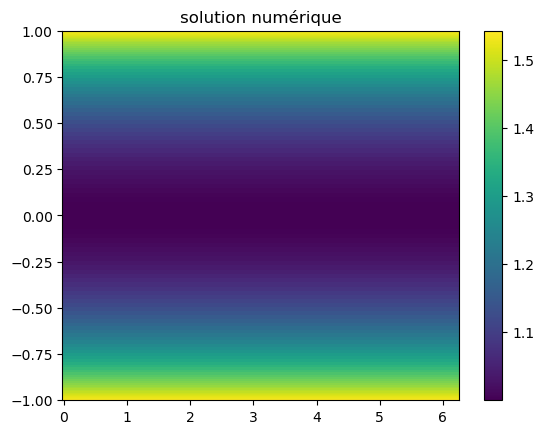

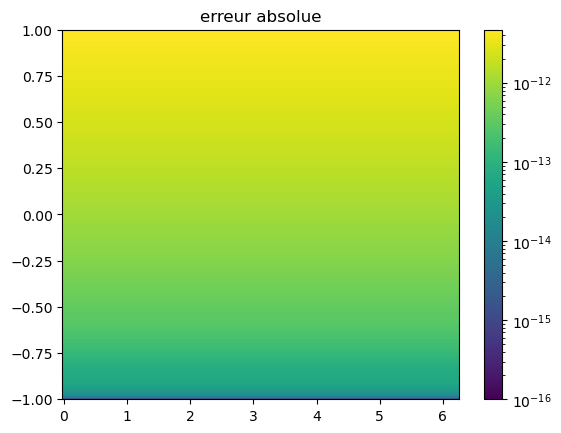

In [121]:
#cas 1D avec psi(x, y) = cosh(y), alpha^2 = 2, rhs = -cosh(y)
Nx= 128
Ny = 128
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2 = 2.*l**2

print(f'alpha^2 {alpha2}')

rhs = -np.cosh(l*Y)

bc_y1 = np.cosh(l) * np.ones(Nx)
bc_ym1 = bc_y1.copy()


psi_analytique = np.cosh(l*Y)

psi_num = Solve_Helmholtz(Nx,
                          Ny,
                          alpha2 = alpha2,
                          rhs = rhs,
                          CL_y_inf = bc_ym1,
                          CL_y_sup = bc_y1,
                          interval_x = (x_inf, x_sup),
                          interval_y = (y_inf, y_sup))

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num)
fig.colorbar(cf, ax=ax)

err = np.abs(psi_analytique - psi_num)
print(f"err {err}, min = {err.min()}, max = {err.max()}, mediane = {np.median(err)}")

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err, norm=colors.LogNorm(vmin=1.0e-16, vmax=err.max()))
fig.colorbar(cf, ax=ax)



Nx = 512
Ny = 512
X.shape (512, 512)
Y.shape (512, 512)
alpha^2 2.0
Préfactorisation
Fait en 2.396 sec
Résolution sur tout le domaine
Fait en 1.198 secondes
erreur min = 0.0, max = 5.822180515480113e-10, mediane = 2.0997731331462433e-11


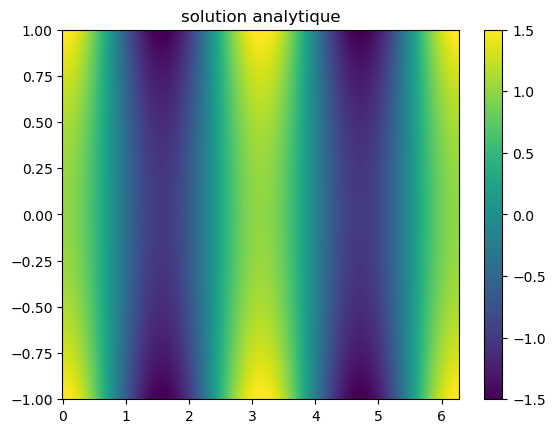

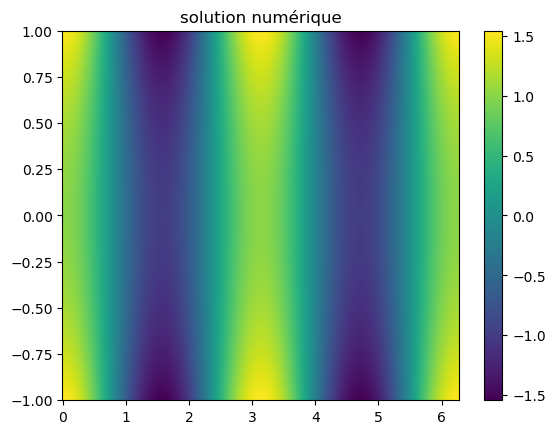

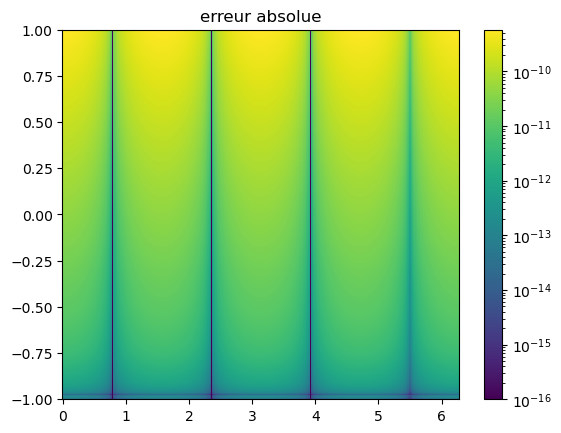

In [127]:
#Cas avec psi(x, y) = 

Nx= 512
Ny = 512
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2_2 = 3.0

print(f'alpha^2 {alpha2}')

bc_y1_2 = np.cos(k*x)*np.cosh(l)
bc_ym1_2 = np.cos(k*x)*np.cosh(l)

#bc_y1_2 = np.cos(k*x)*np.sinh(l)
#bc_ym1_2 = -np.cos(k*x)*np.sinh(l)



psi_analytique_2 = np.cos(k*X)*np.cosh(l*Y)
#psi_analytique_2 = np.cos(k*X)*np.sinh(l*Y)

rhs_2 = (l**2-k**2-alpha2_2)*np.cos(k*X)*np.cosh(l*Y)
#rhs_2 = -6.0*np.cos(k*X)*np.sinh(l*Y)
#rhs_2 = np.zeros((Nx, Ny))

psi_num_2 = Solve_Helmholtz(Nx,
                            Ny,
                            alpha2 = alpha2_2,
                            rhs = rhs_2,
                            CL_y_inf = bc_ym1_2,
                            CL_y_sup = bc_y1_2,
                            interval_x = (x_inf, x_sup),
                            interval_y = (y_inf, y_sup)
                           )
"""
RHS_comp = (Chebyshev.Cheb_derivative_2D(psi_analytique_2, order = 2, axis =0, a = x_inf, b = x_sup)+
            Chebyshev.Cheb_derivative_2D(psi_analytique_2, order = 2, axis =1, a = y_inf, b = y_sup) - alpha2_2 * psi_analytique_2)
"""
VMAX = max(psi_analytique_2.max(), psi_num_2.max())
VMIN = min(psi_analytique_2.min(), psi_num_2.min())

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique_2, vmin = -1.5, vmax = 1.5)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num_2, vmin = VMIN, vmax = VMAX)
fig.colorbar(cf, ax=ax)

err_2 = np.abs(psi_analytique_2 - psi_num_2)
print(f"erreur min = {err_2.min()}, max = {err_2.max()}, mediane = {np.median(err_2)}")
fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err_2, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_2.max()))
fig.colorbar(cf, ax=ax)

Text(0, 0.5, '$\\epsilon$')

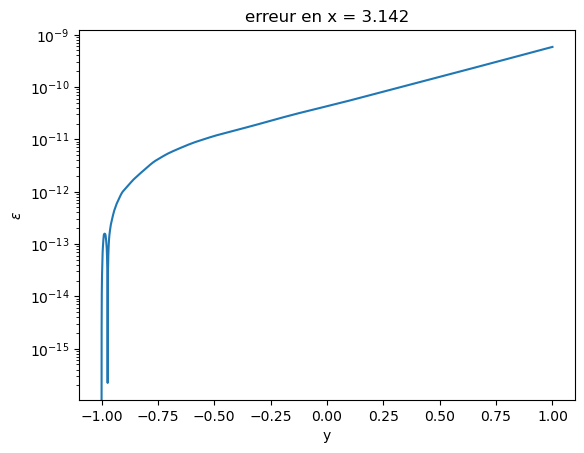

In [128]:
#cas en x = pi
x_sel = np.pi
id_x = np.abs(x-x_sel).argmin()

err_x = np.abs(psi_num_2[id_x, :] - psi_analytique_2[id_x, :])
fig = plt.figure()
plt.title(f"erreur en x = {x[id_x]:.3f}")
plt.semilogy(y, err_x)
plt.xlabel("y")
plt.ylabel(r'$\epsilon$')

Text(0, 0.5, '$|\\hat{\\psi_{ana}} - \\hat{\\psi_{num}}|$')

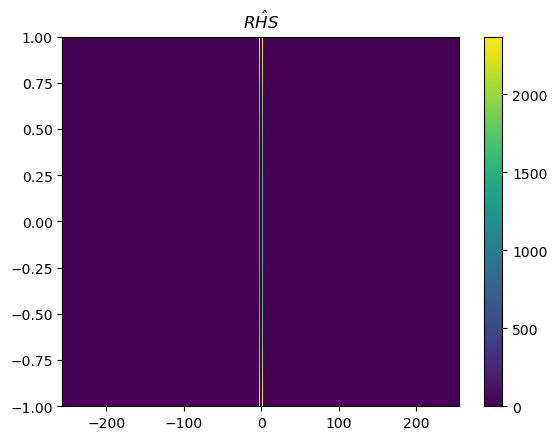

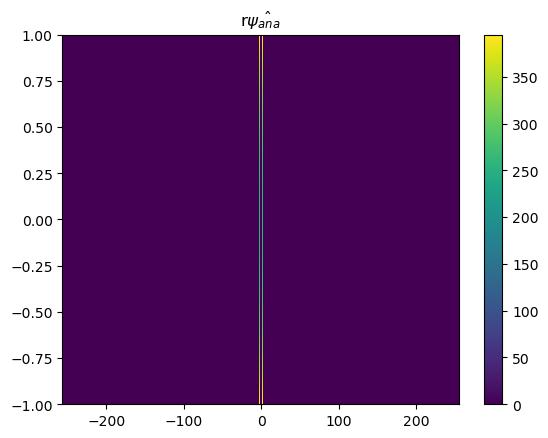

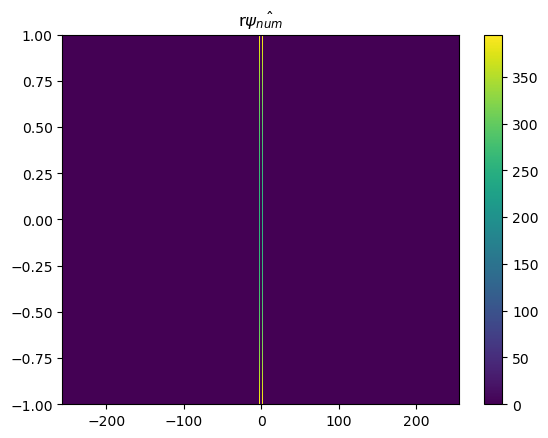

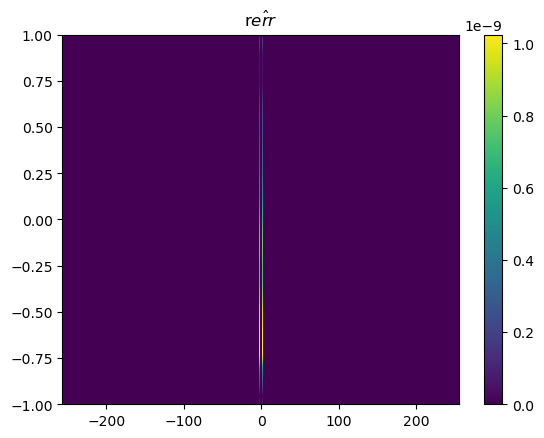

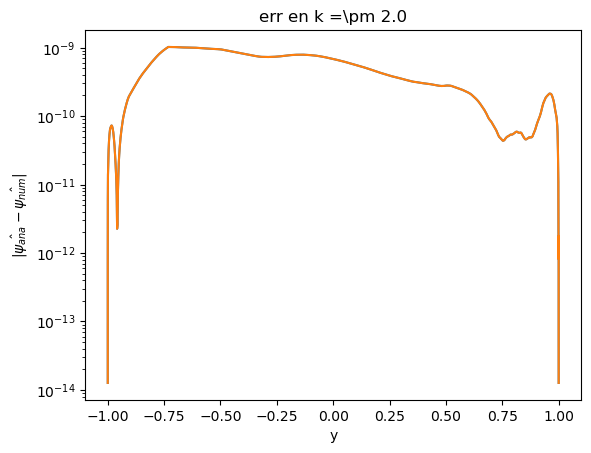

In [51]:
rhs_hat_2 = scipy.fft.fft(rhs_2, axis = 0)
Kx, Y = np.meshgrid(np.sort(kx), y, indexing = 'ij')



fig = plt.figure()
ax=plt.axes()
ax.set_title(r"$\hat{RHS}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(rhs_hat_2, kx)))
fig.colorbar(cf, ax=ax)

psi_ana_hat = scipy.fft.fft(psi_analytique_2, axis =0)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{\psi_{ana}}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(psi_ana_hat, kx)))
fig.colorbar(cf, ax=ax)

psi_num_hat_2 = scipy.fft.fft(psi_num_2, axis =0)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{\psi_{num}}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(psi_num_hat_2, kx)))
fig.colorbar(cf, ax=ax)

err_hat = scipy.fft.fft(psi_num_2 - psi_analytique_2, axis = 0)
fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{err}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(err_hat, kx)))
fig.colorbar(cf, ax=ax)

fig = plt.figure()
plt.title(fr"err en k =\pm {k}")
plt.plot(y, np.abs(err_hat[kx==k][0]), label = f"k={k}")
plt.plot(y, np.abs(err_hat[kx==-k][0]), label = f"k = -{k}")
plt.yscale('log')
plt.xlabel("y")
plt.ylabel(r"$|\hat{\psi_{ana}} - \hat{\psi_{num}}|$")

In [125]:
%timeit Solve_Helmholtz(Nx, Ny, alpha2 = alpha2_2, rhs = rhs_2, CL_y_inf = bc_ym1_2, CL_y_sup = bc_y1_2, interval_x = (x_inf, x_sup), interval_y = (y_inf, y_sup) )

Préfactorisation
Fait en 2.404 sec
Résolution sur tout le domaine
Fait en 1.130 secondes
Préfactorisation
Fait en 2.408 sec
Résolution sur tout le domaine
Fait en 1.311 secondes
Préfactorisation
Fait en 2.418 sec
Résolution sur tout le domaine
Fait en 1.153 secondes
Préfactorisation
Fait en 2.537 sec
Résolution sur tout le domaine
Fait en 1.320 secondes
Préfactorisation
Fait en 2.701 sec
Résolution sur tout le domaine
Fait en 1.318 secondes
Préfactorisation
Fait en 2.715 sec
Résolution sur tout le domaine
Fait en 1.250 secondes
Préfactorisation
Fait en 2.599 sec
Résolution sur tout le domaine
Fait en 1.297 secondes
Préfactorisation
Fait en 2.585 sec
Résolution sur tout le domaine
Fait en 1.178 secondes
3.94 s ± 147 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [61]:
#test sur un système à peu près identique

N = 512
def func_test(n):
    mat = np.random.rand(n, n)
    vec = np.random.rand(n)
    for i in range(0, n):
        sol = np.linalg.solve(mat, vec)
    return 
%timeit func_test(N)

1.9 s ± 213 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [63]:
print(f"{512 * 510 * 510 * 8:.3e}")

1.065e+09


In [82]:
print(f"{512*512*16:.3e}")

4.194e+06
